In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../../../Data Capsule/ROUND_1/prices_round_1_day_-1.csv", sep=";")

# print(df.columns)
# print(df.head())


osmium = df[df["product"] == "ASH_COATED_OSMIUM"].copy()
osmium = osmium.sort_values("timestamp")

osmium = osmium[
    (osmium["bid_price_1"] > 0) &
    (osmium["ask_price_1"] > 0)
]
osmium["mid"] = (osmium["bid_price_1"] + osmium["ask_price_1"]) / 2

osmium_sampled = osmium.iloc[::20]


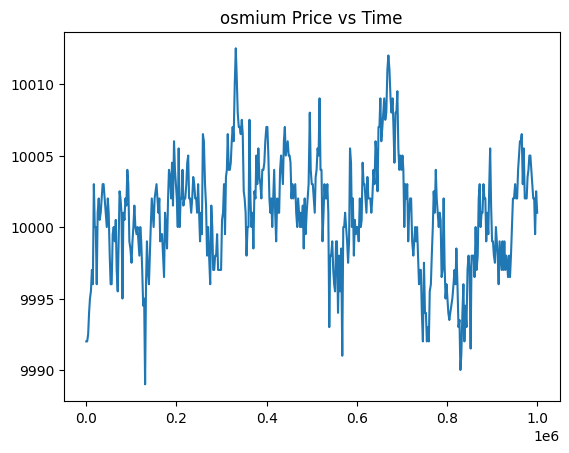

In [2]:
# plot 1 price vs time
plt.figure()
plt.plot(osmium_sampled["timestamp"], osmium_sampled["mid"])
plt.title("osmium Price vs Time")
plt.show()


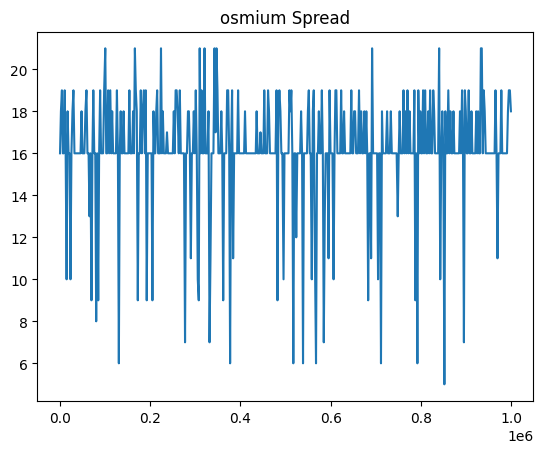

In [3]:
# plot 2 spread vs time
osmium["spread"] = osmium["ask_price_1"] - osmium["bid_price_1"]
osmium_sampled["spread"] = osmium_sampled["ask_price_1"] - osmium_sampled["bid_price_1"]

plt.figure()
# plt.plot(osmium["timestamp"], osmium["spread"])
plt.plot(osmium_sampled["timestamp"], osmium_sampled["spread"])
plt.title("osmium Spread")
plt.show()


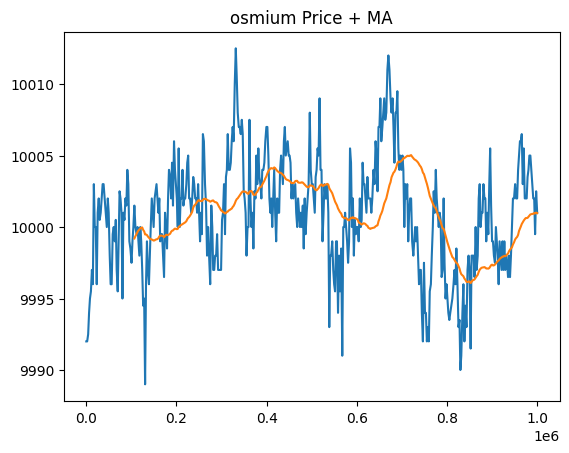

In [4]:
# plot 3 Moving Average
window = 50
osmium_sampled["ma"] = osmium_sampled["mid"].rolling(window).mean()
osmium["ma"] = osmium["mid"].rolling(window).mean()

plt.figure()
plt.plot(osmium_sampled["timestamp"], osmium_sampled["mid"])
plt.plot(osmium_sampled["timestamp"], osmium_sampled["ma"])
# plt.plot(osmium["timestamp"], osmium["mid"])
# plt.plot(osmium["timestamp"], osmium["ma"])
plt.title("osmium Price + MA")
plt.show()

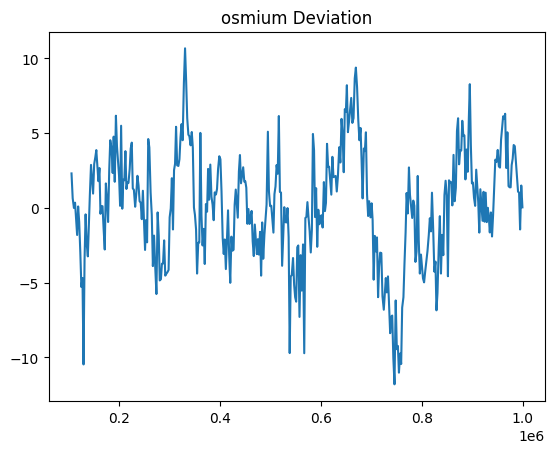

In [5]:
# plot 4 deviation
osmium["dev"] = osmium["mid"] - osmium["ma"]
osmium_sampled["dev"] = osmium_sampled["mid"] - osmium_sampled["ma"]

plt.figure()
plt.plot(osmium_sampled["timestamp"], osmium_sampled["dev"])
# plt.plot(osmium["timestamp"], osmium["dev"])
plt.title("osmium Deviation")
plt.show()

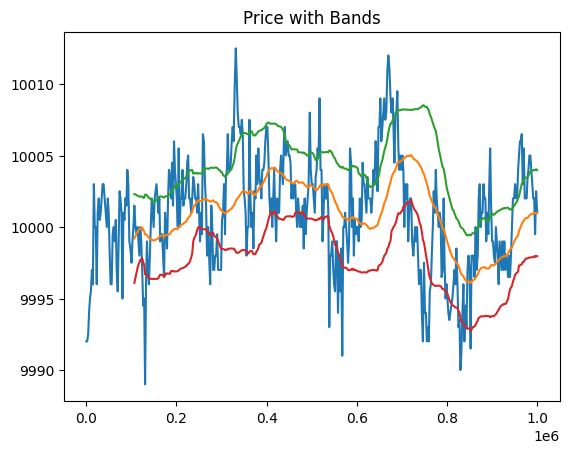

In [6]:
# trying something else
osmium_sampled["std"] = osmium_sampled["mid"].rolling(window).std()
osmium["std"] = osmium["mid"].rolling(window).std()

plt.figure()
plt.plot(osmium_sampled["timestamp"], osmium_sampled["mid"])
plt.plot(osmium_sampled["timestamp"], osmium_sampled["ma"])
plt.plot(osmium_sampled["timestamp"], osmium_sampled["ma"] + osmium_sampled["std"])
plt.plot(osmium_sampled["timestamp"], osmium_sampled["ma"] - osmium_sampled["std"])
plt.title("Price with Bands")
plt.show()

In [7]:
osmium["returns"] = osmium["mid"].diff()

print("Average drift per tick:", osmium["returns"].mean())
print("Deviation mean:", osmium["dev"].mean())
print("Deviation std:", osmium["dev"].std())
print("Deviation min:", osmium["dev"].min())
print("Deviation max:", osmium["dev"].max())
print("Average spread:", osmium["spread"].mean())

Average drift per tick: 0.0010841283607979184
Deviation mean: 0.022033565823890024
Deviation std: 1.8292621419715385
Deviation min: -8.430000000000291
Deviation max: 8.1299999999992
Average spread: 16.19132791327913


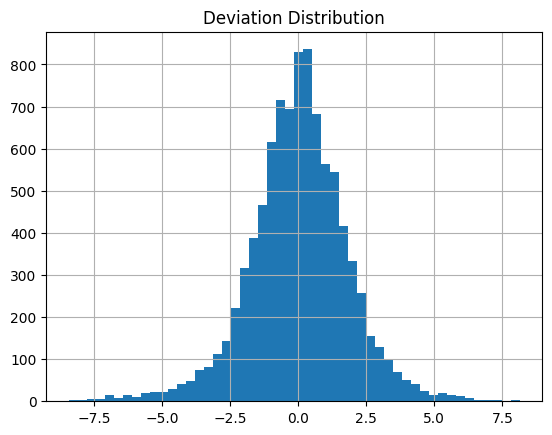

In [8]:
osmium["dev"].hist(bins=50)
plt.title("Deviation Distribution")
plt.show()